In [ ]:
! pip install -U sentence-transformers pandas scikit-learn matplotlib

In [ ]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

sen1 = "I love machine learning"
sen2 = "I like AI"

# Generate the embeddings : which is generating vectors of the sentences
emb1 = model.encode(sen1) 
emb2 = model.encode(sen2)

# Comparing the similarity of the embeddings using cosine
score = util.cos_sim(emb1, emb2)

print("Similarity: ", score)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6702.32it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (10000, 384)
Average Cosine Similarity: 0.54828054


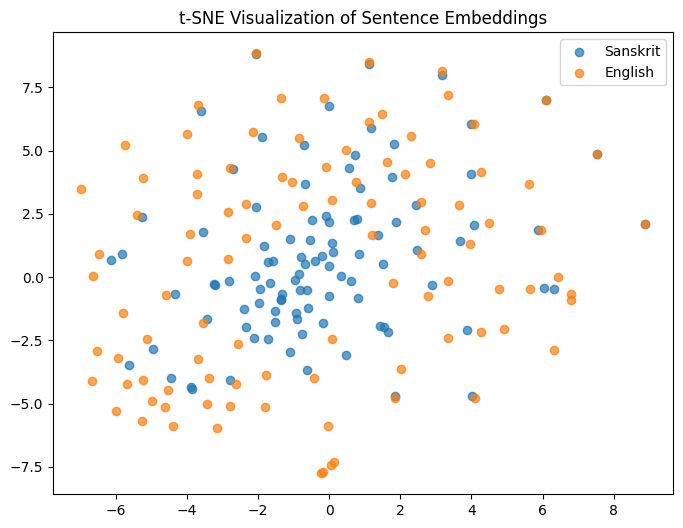

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE


# load training datasets

train_data_sa = pd.read_csv("../data/embedding/train_sa_10000.csv")
train_data_en = pd.read_csv("../data/embedding/train_en_10000.csv")

# merge with source_id

dataFrame = pd.merge(train_data_sa, train_data_en, on='Source_id')

dataFrame.head()




model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

sa_sentence_list = dataFrame['Sentence_sa'].tolist()
en_sentence_list = dataFrame['Sentence_en'].tolist()

sa_embgging_data = model.encode(sa_sentence_list)
en_enbedding_data = model.encode(en_sentence_list)

print("Embedding shape:", sa_embgging_data.shape)
print("Embedding shape:", en_enbedding_data.shape)

cosine_similarity_matrix = cosine_similarity(sa_embgging_data, en_enbedding_data)

similarity_diagonal = cosine_similarity_matrix.diagonal()

avarage_similarity = np.mean(similarity_diagonal)
print("Average Cosine Similarity:", avarage_similarity)


# Take 100 samples
sa_sample = sa_embgging_data[:100]
en_sample = en_enbedding_data[:100]

combined = np.vstack((sa_sample, en_sample))

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(combined)

# Split back
sa_2d = reduced[:100]
en_2d = reduced[100:]

plt.figure(figsize=(8,6))

plt.scatter(sa_2d[:,0], sa_2d[:,1], label="Sanskrit", alpha=0.7)
plt.scatter(en_2d[:,0], en_2d[:,1], label="English", alpha=0.7)

plt.legend()
plt.title("t-SNE Visualization of Sentence Embeddings")
plt.show()
